# How to train a Restricted Kirchhoff Machine
Welcome to pyrkm!
In this example I will guide you through the process of training a Restricted Kirchhoff Machine (RKM) on the MNIST dataset.

First we import the required libraries.

In [1]:
from __future__ import annotations

import glob
import os
import pickle
import sys  # noqa: F401

import matplotlib as mpl  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # noqa: F401
import torch

import pyrkm

We now set the desired data type and device for the computations.

In [2]:
# Torch operations: set double type
torch.set_default_dtype(torch.float64)

# Select which gpu you want to use if a multi-gpu system
gpu_id = 0
os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_id)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device == "cpu":
    # otherwise use multicore-CPU
    torch.set_num_threads(24)
print(device)

# Fix the seed for reproducibility
torch.manual_seed(42)

cuda


Create the directories to store the data and the model.

In [3]:
pyrkm.ensure_dir("model_states")
pyrkm.ensure_dir("model_measure")

### Load the data
For this example we will use the MNIST dataset. We have created a [submodule](https://github.com/Kirchhoff-Machines/datasets) that contains some cleaned dataset that have been tested. 

**Important**: If you have cloned the `pyrkm` repository, be sure that you have initialized the submodule correctly:
```bash
git submodule init
git submodule update
```

If the datasets are not available, you can download them directly from [https://github.com/Kirchhoff-Machines/datasets](https://github.com/Kirchhoff-Machines/datasets).

In [4]:
import os
import subprocess
import urllib.request
from os.path import exists

# Path where the dataset should be if submodules are initialized
submodule_path = "../../datasets/MNIST-120k"

# Alternative path to avoid polluting the datasets directory if submodules are not used
alt_path = "MNIST-120k"

# Raw URL for the dataset
url = "https://github.com/Kirchhoff-Machines/datasets/raw/44cb78c1c767f5d8fc32fa6b356f0935ef3a03b7/MNIST-120k"

data_path = None

if exists(submodule_path):
    print(f"Found dataset at {submodule_path}")
    data_path = submodule_path
elif exists(alt_path):
    print(f"Found dataset at {alt_path}")
    data_path = alt_path
else:
    print("Dataset not found. Attempting to initialize submodule...")
    try:
        # Try to initialize the submodule
        subprocess.check_call(["git", "submodule", "update", "--init", "--recursive"], cwd="../..")
        if exists(submodule_path):
            print(f"Submodule initialized. Dataset found at {submodule_path}")
            data_path = submodule_path
    except (subprocess.CalledProcessError, FileNotFoundError):
        print("Submodule initialization failed/not available.")

    if data_path is None:
        print(f"Downloading {alt_path} from {url}...")
        urllib.request.urlretrieve(url, alt_path)
        print("Download complete.")
        data_path = alt_path

Dataset not found. Attempting to initialize submodule...


Submodule 'datasets' (git@github.com:Kirchhoff-Machines/datasets.git) registered for path 'datasets'
Submodule 'energy_consumption' (git@github.com:Kirchhoff-Machines/rkm_energy.git) registered for path 'energy_consumption'
Cloning into '/home/simone/pyrkm/datasets'...
Cloning into '/home/simone/pyrkm/energy_consumption'...


Submodule path 'datasets': checked out '44cb78c1c767f5d8fc32fa6b356f0935ef3a03b7'
Submodule path 'energy_consumption': checked out '2ab999afec869746a62013fcdc53916a963f1776'
Submodule initialized. Dataset found at ../../datasets/MNIST-120k


In [5]:
# Load data
qmnist = pyrkm.unpickle(data_path)
data = qmnist["data"]
train_data = np.reshape(data, shape=(data.shape[0], 784)) / 255

/home/simone/pyrkm/src/pyrkm/utils.py:507: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding="bytes")  # nosec B301


We now separate the data into training and testing sets and binarize the images. Following this [Ref.](https://proceedings.neurips.cc/paper/2021/hash/2aedcba61ca55ceb62d785c6b7f10a83-Abstract.html) we only use the first 10000 samples for training.

In [6]:
testing_data = train_data[:500, :]
testing_labels = qmnist["labels"][:500]
train_data = train_data[500:]
train_labels = qmnist["labels"][500:]

testing_data = torch.Tensor(testing_data)

# Use only 10000 data as Literature
train_data = torch.Tensor(train_data[:10000])
# and make them already binary
train_data = torch.where(train_data > 0.5, 1.0, 0.0).to(torch.float)
testing_data = torch.where(testing_data > 0.5, 1.0, 0.0).to(torch.float)

Let's plot some samples to see how they look like:

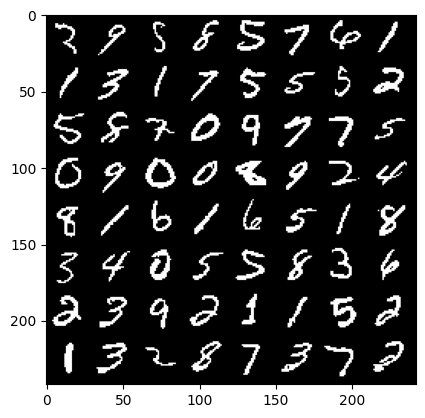

In [7]:
examples = pyrkm.make_grid(np.reshape(train_data[:64], shape=(-1, 28, 28)))
plt.imshow(examples, cmap="gray")

## Training
To train the RKM we need to define the architecture of the model and the hyperparameters. In the block below we make a standard choice that will produce acceptable results for this example. If you want to know more about the specific parameters you can look at the [documentation of the `RKM` class](https://kirchhoff-machines.github.io/pyrkm/api/rkm/#pyrkm.rkm.RKM).

In [8]:
# Model parameters
max_epochs = 100000
batch_size = 64
lr = 0.001
optimizer = "SGD"
energy_type = "hopfield"
nhidden = 50
minWeight = -20
maxWeight = 20
regul_to_use = "l2"
l1factor = 1e-2
l2factor = 1e-2
k = 1
train_algo = "PCD"
centering = False
out_infix = "test"
average_data = torch.Tensor(train_data).mean(0).to(torch.double)
model_beta = 1
mytype = torch.float32

and perpare the data to be loaded efficiently

In [9]:
# Set the data type
train_data = train_data.to(mytype)
testing_data = testing_data.to(mytype)
# Perepare the batchloader
train_loader = torch.utils.data.DataLoader(
    train_data.to(device), batch_size=batch_size, shuffle=True, drop_last=True
)

Before creating the model, we give it a unique name that will identify univoquely the model in the filesystem.

In [10]:
# Define the model name
model_name = "nh{}_{}{}_".format(nhidden, energy_type, max_epochs)
if model_beta < 1000:
    model_name = "{}beta{}_".format(model_name, model_beta)
else:
    model_name = "{}Deterministic_".format(model_name)
if regul_to_use == "l2":
    model_name = "{}l2{}_".format(model_name, l2factor)
if regul_to_use == "l1":
    model_name = "{}l1{}_".format(model_name, l1factor)
model_name = "{}{}{}_{}_lr{}_bs{}_{}".format(model_name, train_algo, k, optimizer, lr, batch_size, out_infix)
print("*** {} ***".format(model_name), flush=True)

*** nh50_hopfield100000_beta1_l20.01_PCD1_SGD_lr0.001_bs64_test ***


After checking that the model does not already exist, we initialize the model

In [11]:
# *****  Load the model and Train
# check if previous save point is available
is_loadable, model = pyrkm.load_model(model_name, delete_previous=False)
if not is_loadable:
    # *** Initialize
    model = pyrkm.RKM(
        model_name=model_name,
        n_visible=784,
        n_hidden=nhidden,
        k=k,
        lr=lr,
        max_epochs=max_epochs,
        energy_type=energy_type,
        optimizer=optimizer,
        batch_size=batch_size,
        train_algo=train_algo,
        centering=centering,
        average_data=average_data,
        model_beta=model_beta,
        mytype=mytype,
    )

** Model nh50_hopfield100000_beta1_l20.01_PCD1_SGD_lr0.001_bs64_test trained up to epoch 100000, so I load it


Notice that it is possible to initialize the model from the trained state of another one with a compatible architecture. To do so you can uncomment the block below.

In [12]:
# if not is_loadable:
#    pretrain_source = 'another_trained_compatible_model'
#    model.pretrain(pretrain_source)

We can finally perform the training!

In [13]:
model.train(train_loader, testing_data.to(model.device), print_error=True)

*** Training finished


## Visualization
`pyrkm` provides some tools to visualize the training process and give you an idea of how the model is learning. 
First, we can plot weights and biases of the model:

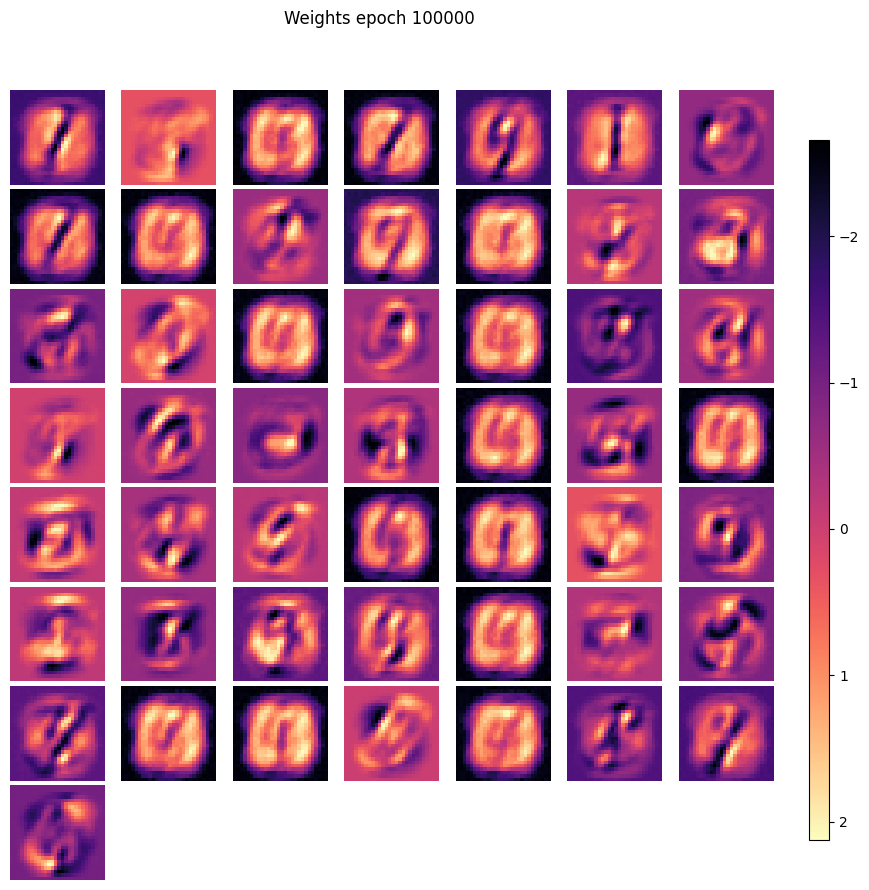

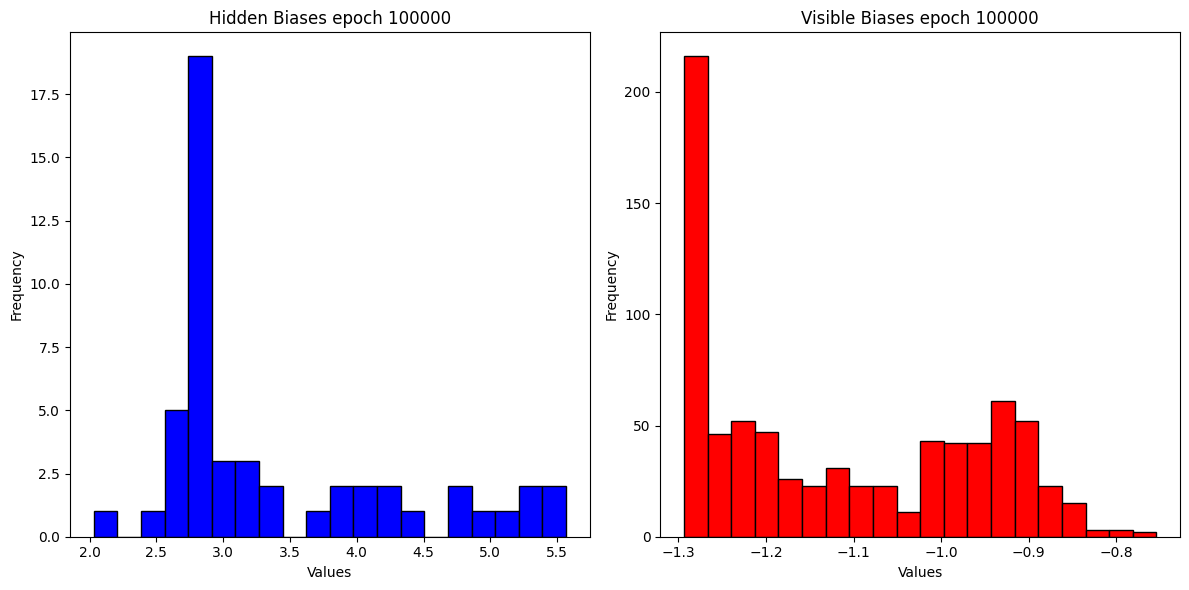

In [14]:
if hasattr(model, "energy_type"):
    # Visualize the weights using a grid. Each grid contains the weights for a single hidden unit
    model.plot_weights(max_epochs)
    plt.show()
    # The biases are plotted as a histogram
    model.plot_bias(max_epochs)
    plt.show()

We can then show the performance of the model in reconstructing the input data. It is interesting to see how the reconstruction appears for different number of gibbs steps (`k`). Notice that while `k` was fixed during training, it can be changed during inference.

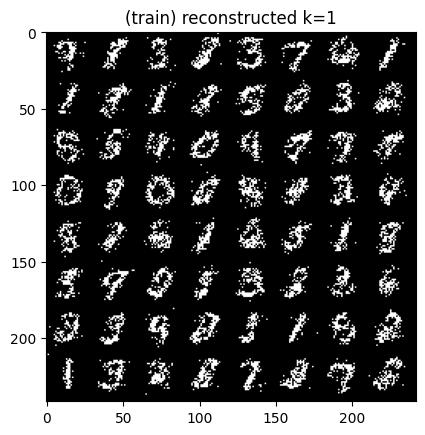

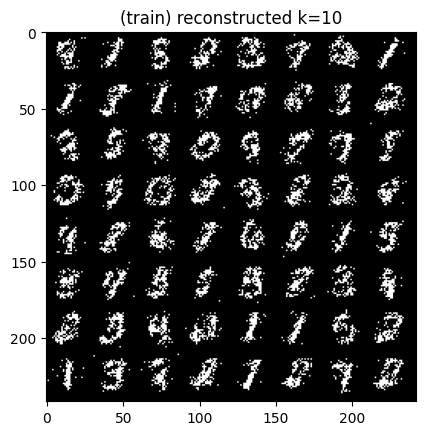

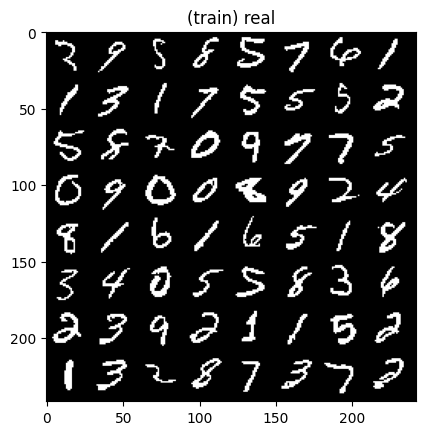

In [15]:
# Reconstruct some of the training data
testing_data = train_data[:64]
k_gibbs_list = [1, 10]
for tg_multiple in k_gibbs_list:
    v_original, v_reconstructed = model.reconstruct(testing_data, tg_multiple * k)
    pyrkm.show_and_save(
        "(train) reconstructed k={}".format(tg_multiple * k),
        pyrkm.make_grid(np.reshape(v_reconstructed, shape=(-1, 28, 28))),
        save=False,
    )
    plt.show()
pyrkm.show_and_save("(train) real", pyrkm.make_grid(np.reshape(v_original, shape=(-1, 28, 28))))
plt.show()

## Generative performance
We now look at how good the model is at generating new samples. Notice that usually in studies about RBM generative features, it is often reported the *persistent chain* as 'generated' output. Here instead we generate new samples in real time starting from random noise, to mimick the real use case of the RKM:

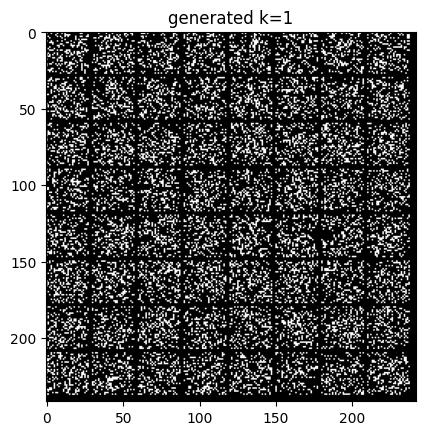

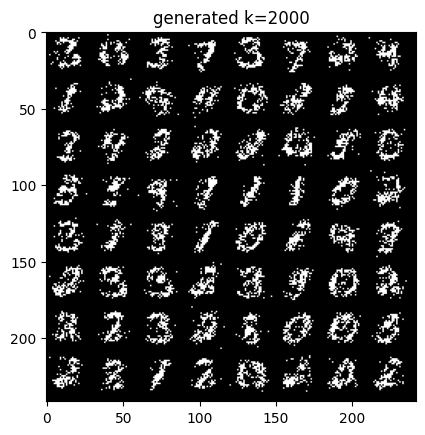

In [16]:
gsteps_list = [1, 2000]
for tg_multiple in gsteps_list:
    v_generated = model.generate(64, tg_multiple * k, from_visible=True)
    pyrkm.show_and_save(
        "generated k={}".format(tg_multiple * k),
        pyrkm.make_grid(np.reshape(v_generated, shape=(-1, 28, 28))),
    )
    plt.show()

## Measures
We can now measure and plot the most interesting observables to asses the model performance.
We will measure multiple observables at the same time, and with a similar loop you will be able to reproduce the plots reported in XXX that quantify the performance improvement during training.

In [17]:
# Get all the intermediate states
filename_list = glob.glob("model_states/{}_t*.pkl".format(model_name))
all_loadpoints = sorted([int(x.split("_t")[-1].split(".pkl")[0]) for x in filename_list])

# Prepare a list of all the measures
energy_array = []
power_forward_array = []
power_backward_array = []
time_forward_array = []
time_backward_array = []
av_time_forward_array = []
av_time_backward_array = []
rec_error_train_array = []
rec_error_test_array = []
entropy_array = []
fid_array = []

# Loop over all the loadpoints and measure the physical quantities
for t in all_loadpoints:
    with open("model_states/{}_t{}.pkl".format(model_name, t), "rb") as file:
        model = pickle.load(file)
        # physical measures
        energy_array.append(model.energy.cpu().numpy())
        power_forward_array.append(model.power_f.cpu().numpy())
        power_backward_array.append(model.power_b.cpu().numpy())
        t_f = model.relax_t_f.cpu().numpy()
        t_b = model.relax_t_b.cpu().numpy()
        time_forward_array.append(t_f)
        time_backward_array.append(t_b)
        av_time_forward_array.append(t_f.mean())
        av_time_backward_array.append(t_b.mean())

        # errors
        k = model.k
        # Compute reconstruction error (averaged over pixels and samples)
        v_model = model.forward(train_data.to(model.device), k)
        rec_error_train = ((v_model - train_data.to(model.device)) ** 2).mean(1).mean(0)
        # Now compute the reconstruction error for the test set only
        v_model = model.forward(testing_data.to(model.device), k)
        rec_error_test = ((v_model - testing_data.to(model.device)) ** 2).mean(1).mean(0)
        rec_error_train_array.append(rec_error_train.cpu().numpy())
        rec_error_test_array.append(rec_error_test.cpu().numpy())

        # Entropy
        v_generated = model.generate(testing_data.shape[0], k, from_visible=True)
        entropy_array.append(pyrkm.Compute_S(testing_data.to(model.device), v_generated))

        # FID
        fid = pyrkm.Compute_FID(testing_data.to(model.device), v_generated)
        fid_array.append(fid)

# transform to np array
energy_array = np.array(energy_array)
power_forward_array = np.array(power_forward_array)
power_backward_array = np.array(power_backward_array)
time_forward_array = np.array(time_forward_array)
time_backward_array = np.array(time_backward_array)
av_time_forward_array = np.array(av_time_forward_array)
av_time_backward_array = np.array(av_time_backward_array)
rec_error_train_array = np.array(rec_error_train_array)
rec_error_test_array = np.array(rec_error_test_array)
entropy_array = np.array(entropy_array)
fid_array = np.array(fid_array)

/home/simone/pyrkm/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/simone/pyrkm/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


We can finally plot the observables to see how the model is learning.

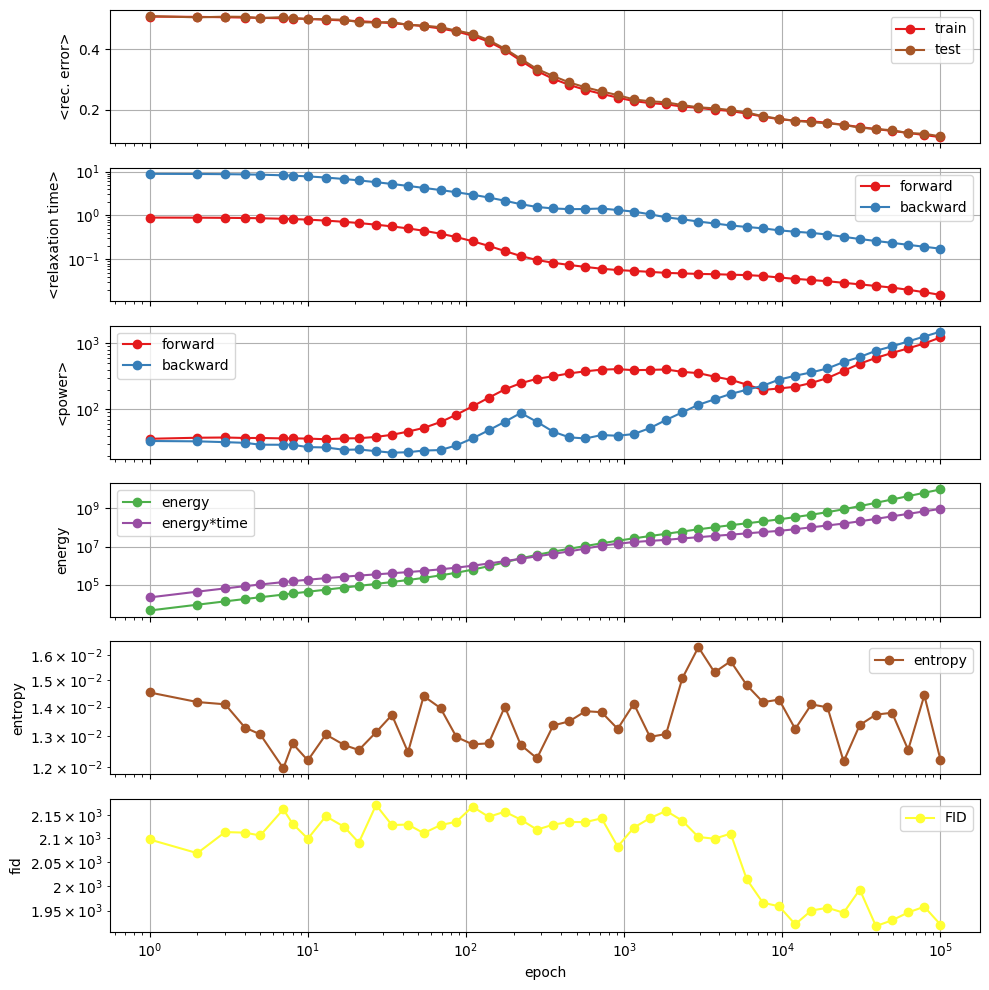

In [ ]:
fig, axs = plt.subplots(6, 1, figsize=(10, 10), sharex=True, tight_layout=True)
cmap = plt.colormaps["Set1"]
colors = [cmap(i) for i in range(7)]
axs[0].plot(all_loadpoints, rec_error_train_array, "-o", label="train", color=colors[0])
axs[0].plot(all_loadpoints, rec_error_test_array, "-o", label="test", color=colors[6])
axs[1].plot(all_loadpoints, av_time_forward_array, "-o", label="forward", color=colors[0])
axs[1].plot(all_loadpoints, av_time_backward_array, "-o", label="backward", color=colors[1])
axs[2].plot(all_loadpoints, power_forward_array, "-o", label="forward", color=colors[0])
axs[2].plot(all_loadpoints, power_backward_array, "-o", label="backward", color=colors[1])
axs[3].plot(all_loadpoints, energy_array, "-o", label="energy", color=colors[2])
axs[3].plot(
    all_loadpoints,
    energy_array * (av_time_backward_array + av_time_forward_array) / 2,
    "-o",
    label="energy*time",
    color=colors[3],
)
axs[4].plot(all_loadpoints, entropy_array, "-o", label="entropy", color=colors[-1])
axs[5].plot(all_loadpoints, fid_array, "-o", label="FID", color=colors[-2])

axs[0].set_ylabel("<rec. error>")
axs[1].set_ylabel("<relaxation time>")
axs[2].set_ylabel("<power>")
axs[3].set_ylabel("energy")
axs[4].set_ylabel("entropy")
axs[5].set_ylabel("fid")

[ax.legend() for ax in axs]

axs[-1].set_xlabel("epoch")

[ax.set_yscale("log") for ax in axs[1:]]
[ax.set_xscale("log") for ax in axs]
[ax.grid() for ax in axs]

plt.show()

You reached the end of this tutorial! I hope you enjoyed it and that you are now ready to train your own RKM. If you have any question, feel free to contact one of the developers or open an issue on the [GitHub repository](https://github.com/Kirchhoff-Machines/pyrkm/issues)